#ML Regression from Scratch - Notebook 3: Linear Regression (Full Dataset, 5 Features)

**Goal:** predict `CapstoneScore` from **five** student features instead of
one, using multi-dimensional gradient descent - still built entirely from
scratch with NumPy.

|Feature name      | Column used in this dataset |
|---|---|
| `attendance_rate`            | `Attendance` |
| `study_hours_normalized`     | `TotalHours` |
| `assignment_submission_rate` | `AssignmentsCompleted` |
| `avg_quiz_score`             | `GitHubScore`  |
| `participation_level`        | `PeerReviewScore`  |

(`HackathonParticipation` and `EducationLevel` exist in the raw data but
are left out to keep exactly five features, matching the spec.)

We will:
1. Load the data and explore all five features
2. Split into train/test and **scale every feature** (this is not optional
   with 5 features of very different ranges)
3. Implement multi-dimensional `compute_cost`, `compute_gradients`,
   `gradient_descent`, `predict` using matrix/vector operations
4. Train the model, check convergence, and evaluate it
5. Interpret the (standardized) coefficients to see which features matter most

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

## 1. Load & explore the data

In [30]:
df = pd.read_csv('student scores.csv')
df = df[df['CourseName'] == 'Foundations of ML'].reset_index(drop=True)
print(f"Rows: {len(df)}")

feature_cols = ['Attendance', 'TotalHours', 'AssignmentsCompleted', 'GitHubScore', 'PeerReviewScore']
target_col = 'CapstoneScore'

df[feature_cols + [target_col]].describe()

Rows: 72


,Attendance,TotalHours,AssignmentsCompleted,GitHubScore,PeerReviewScore,CapstoneScore
count,72.000000,72.000000,72.000000,72.000000,72.000000,72.000000
mean,78.841667,56.125000,5.763889,56.658333,3.069444,55.108333
std,11.261698,26.623154,2.635046,30.078207,1.230783,17.022138
min,60.500000,10.500000,2.000000,4.600000,1.000000,23.300000
25%,69.125000,36.050000,4.000000,26.450000,1.900000,40.250000
50%,78.550000,55.600000,6.000000,66.400000,3.250000,54.750000
75%,86.500000,78.725000,8.000000,82.000000,4.125000,68.300000
max,99.400000,98.800000,10.000000,99.500000,5.000000,89.300000


Each feature lives on a very different scale - `Attendance` is roughly
60-100, `TotalHours` roughly 10-100, `AssignmentsCompleted` is 2-10,
`GitHubScore` is 0-100, and `PeerReviewScore` is 1-5. That alone tells us
scaling is essential before gradient descent (exactly the lesson from
Notebooks 1 and 2, now with five different scales at once instead of one).

In [31]:
correlations = df[feature_cols + [target_col]].corr()[target_col].drop(target_col)
print("Correlation of each feature with CapstoneScore:")
print(correlations.sort_values(ascending=False))

Correlation of each feature with CapstoneScore:
TotalHours              0.955447
AssignmentsCompleted    0.158335
GitHubScore             0.123862
PeerReviewScore         0.097552
Attendance              0.039808
Name: CapstoneScore, dtype: float64


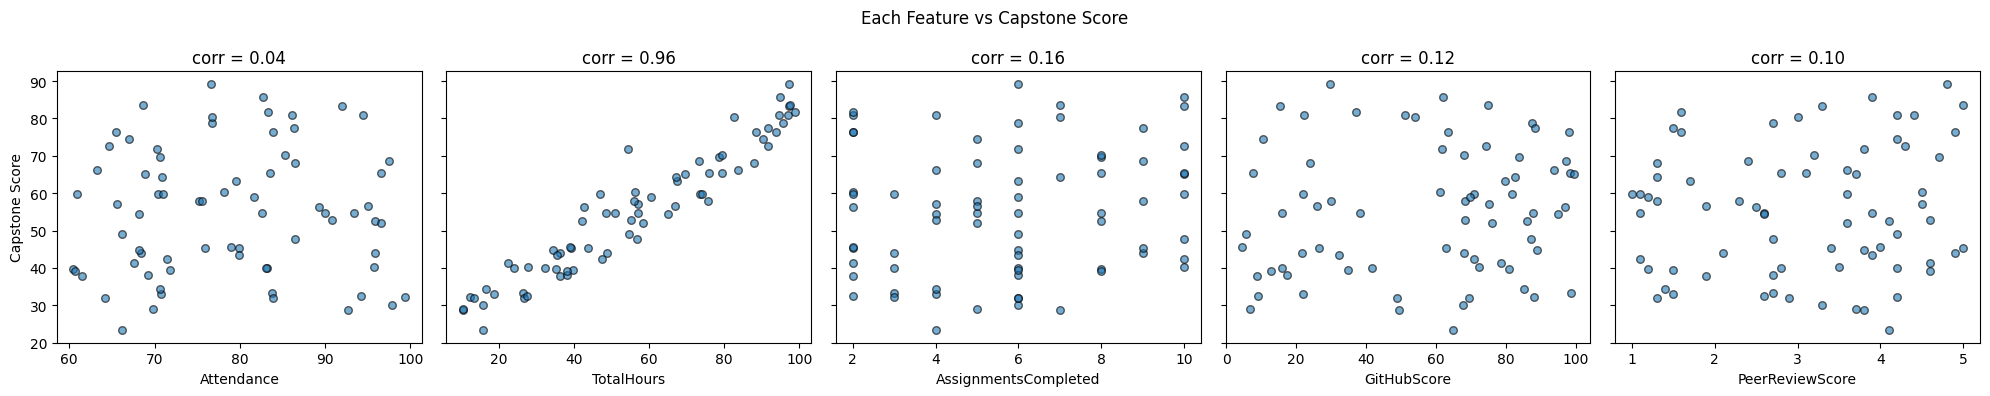

In [32]:
fig, axes = plt.subplots(1, 5, figsize=(20,4), sharey=True)
for ax, col in zip(axes, feature_cols):
    ax.scatter(df[col], df[target_col], alpha=0.6, s=30, edgecolor='k')
    ax.set_xlabel(col)
    ax.set_title(f"corr = {correlations[col]:.2f}")
axes[0].set_ylabel('Capstone Score')
plt.suptitle('Each Feature vs Capstone Score')
plt.tight_layout()
plt.show()

`TotalHours` (our proxy for `study_hours_normalized`) stands out with a
much stronger correlation than the others — worth keeping in mind when we
look at the learned coefficients later.

## 2. Train/test split and feature matrix

`X` is now a **matrix** (m rows × 5 columns) instead of a single vector.

In [33]:
def train_test_split_scratch(X, Y, test_size=0.2, seed=42):
    """Shuffle-and-slice split. X can be 1-D or 2-D (m, n)."""
    m = len(Y)
    rng = np.random.RandomState(seed)
    shuffled_idx = rng.permutation(m)
    n_test = int(m * test_size)
    test_idx = shuffled_idx[:n_test]
    train_idx = shuffled_idx[n_test:]
    return X[train_idx], X[test_idx], Y[train_idx], Y[test_idx]


X = df[feature_cols].values.astype(float)   # shape (m, 5)
Y = df[target_col].values.astype(float)     # shape (m,)

X_train, X_test, Y_train, Y_test = train_test_split_scratch(X, Y, test_size=0.2, seed=42)
print(f"X_train shape: {X_train.shape},  X_test shape: {X_test.shape}")

X_train shape: (58, 5),  X_test shape: (14, 5)


## 3. Feature scaling

Standardize every column using **train-set statistics only** (the test set
must never influence the scaling, or we'd be leaking information about it
into training).

In [34]:
def standardize_features(X, mu=None, sigma=None):
    """
    Z-score standardize each column of a 2-D feature matrix.
    Pass mu/sigma (from a previous call on the training set) to apply the
    exact same transform to new data, e.g. the test set.
    """
    if mu is None or sigma is None:
        mu = X.mean(axis=0)
        sigma = X.std(axis=0)
    X_scaled = (X - mu) / sigma
    return X_scaled, mu, sigma


def add_bias(X):
    """Prepend a column of ones for the intercept term."""
    return np.column_stack([np.ones(len(X)), X])


X_train_scaled, mu, sigma = standardize_features(X_train)
X_test_scaled, _, _ = standardize_features(X_test, mu, sigma)   # reuse train mu/sigma

X_train_design = add_bias(X_train_scaled)
X_test_design = add_bias(X_test_scaled)

print(f"Design matrix shape (with bias column): {X_train_design.shape}")
print(f"Train feature means after scaling (should be ~0): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Train feature stds after scaling (should be ~1):  {X_train_scaled.std(axis=0).round(4)}")

Design matrix shape (with bias column): (58, 6)
Train feature means after scaling (should be ~0): [-0. -0.  0. -0.  0.]
Train feature stds after scaling (should be ~1):  [1. 1. 1. 1. 1.]


## 4. Multi-dimensional gradient descent, from scratch

With $n$ features the hypothesis becomes a dot product:

$$\hat{y}_i = \theta_0 + \theta_1 x_{i1} + \theta_2 x_{i2} + \dots + \theta_n x_{in} = \mathbf{x}_i^\top \boldsymbol\theta$$

where $\mathbf{x}_i$ is row $i$ of the design matrix (with a leading 1 for
the bias). Stacking all $m$ rows gives $\hat{\mathbf y} = X\boldsymbol\theta$.

**Cost** (identical form to the single-feature case, just with vectors):

$$J(\boldsymbol\theta) = \frac{1}{2m}\sum_{i=1}^m(\hat y_i - y_i)^2 = \frac{1}{2m}\lVert X\boldsymbol\theta - \mathbf y\rVert^2$$

**Gradient** (one derivative per parameter, computed all at once via a
matrix multiply):

$$\nabla J(\boldsymbol\theta) = \frac{1}{m}X^\top(X\boldsymbol\theta - \mathbf y)$$

**Update:** $\boldsymbol\theta := \boldsymbol\theta - \alpha\nabla J(\boldsymbol\theta)$ — exactly
the same rule as before, just updating all $n+1$ parameters together.

In [35]:
def compute_cost(X_design, y, theta):
    """
    Mean-squared-error cost for multi-feature linear regression.

    X_design : (m, n+1) design matrix, bias column already included
    y        : (m,) target vector
    theta    : (n+1,) parameter vector, theta[0] is the intercept
    """
    m = len(y)
    y_hat = X_design.dot(theta)
    return (1 / (2 * m)) * np.sum((y_hat - y) ** 2)


def compute_gradients(X_design, y, theta):
    """Vectorised gradient of the MSE cost w.r.t. every theta_j at once."""
    m = len(y)
    y_hat = X_design.dot(theta)
    return (1 / m) * X_design.T.dot(y_hat - y)


def gradient_descent(X_design, y, learning_rate, n_iterations=3000, theta_init=None):
    """
    Batch gradient descent for multi-feature linear regression.

    Returns theta, cost_history (list, one entry per completed iteration —
    stops early if the cost becomes non-finite).
    """
    n = X_design.shape[1]
    theta = np.zeros(n) if theta_init is None else theta_init
    cost_history = []

    for i in range(n_iterations):
        cost = compute_cost(X_design, y, theta)
        if not np.isfinite(cost):
            break
        cost_history.append(cost)
        theta = theta - learning_rate * compute_gradients(X_design, y, theta)

    return theta, cost_history


def predict(X_design, theta):
    """Vectorised prediction for a design matrix that already has the bias column."""
    return X_design.dot(theta)

## 5. Evaluation metrics (same as Notebooks 1 & 2)

In [36]:
def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def evaluate(y_true, y_pred):
    return {
        'MSE':  mean_squared_error(y_true, y_pred),
        'RMSE': root_mean_squared_error(y_true, y_pred),
        'MAE':  mean_absolute_error(y_true, y_pred),
        'R2':   r2_score(y_true, y_pred),
    }

## 6. Train the model

In [37]:
LEARNING_RATE = 0.1
N_ITERATIONS = 3000

theta, cost_history = gradient_descent(X_train_design, Y_train, LEARNING_RATE, N_ITERATIONS)

print(f"Converged in {len(cost_history)} iterations")
print(f"Final training cost: {cost_history[-1]:.4f}")
print(f"Learned theta (bias, then one weight per standardized feature):")
for name, value in zip(['bias'] + feature_cols, theta):
    print(f"  {name:<22} {value:8.4f}")

Converged in 3000 iterations
Final training cost: 10.6411
Learned theta (bias, then one weight per standardized feature):
  bias                    56.1586
  Attendance               0.3872
  TotalHours              17.0320
  AssignmentsCompleted    -0.2986
  GitHubScore              0.6705
  PeerReviewScore          1.4097


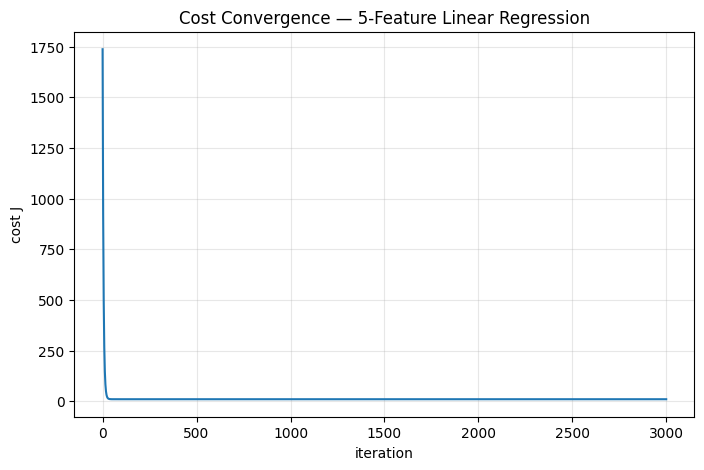

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history)
plt.xlabel("iteration")
plt.ylabel("cost J")
plt.title("Cost Convergence — 5-Feature Linear Regression")
plt.grid(alpha=0.3)
plt.show()

## 7. Evaluate on train and test sets

In [39]:
y_pred_train = predict(X_train_design, theta)
y_pred_test = predict(X_test_design, theta)

train_metrics = evaluate(Y_train, y_pred_train)
test_metrics = evaluate(Y_test, y_pred_test)

metrics_df = pd.DataFrame([train_metrics, test_metrics], index=['train', 'test'])
metrics_df.round(4)

,MSE,RMSE,MAE,R2
train,21.2822,4.6133,3.5333,0.9335
test,23.8441,4.8830,4.1930,0.8024


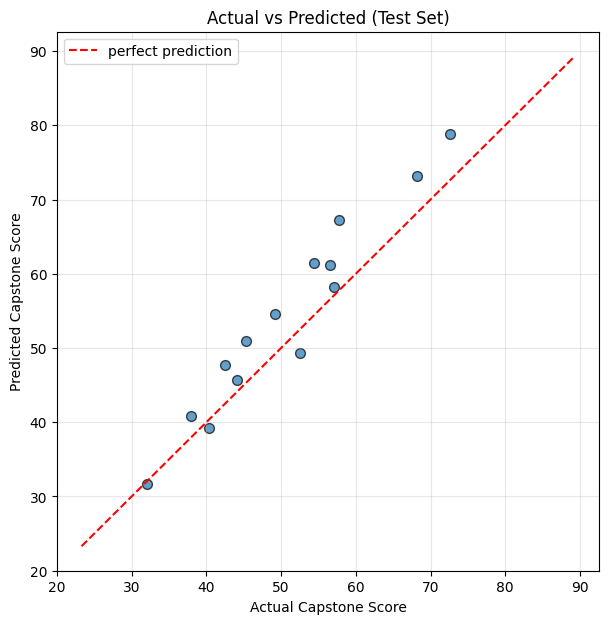

In [40]:
plt.figure(figsize=(7, 7))
plt.scatter(Y_test, y_pred_test, s=50, alpha=0.7, edgecolor='k')
lims = [min(Y.min(), y_pred_test.min()), max(Y.max(), y_pred_test.max())]
plt.plot(lims, lims, 'r--', label='perfect prediction')
plt.xlabel('Actual Capstone Score')
plt.ylabel('Predicted Capstone Score')
plt.title('Actual vs Predicted (Test Set)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 8. Interpreting the coefficients

Because every feature was standardized before training, the learned
weights are directly comparable to each other — a larger magnitude means
that feature moves the prediction more per one-standard-deviation change,
regardless of the feature's original units.

In [41]:
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'standardized_weight': theta[1:],
}).sort_values('standardized_weight', key=abs, ascending=False)

coef_df

,feature,standardized_weight
1,TotalHours,17.032037
4,PeerReviewScore,1.409698
3,GitHubScore,0.670459
0,Attendance,0.387212
2,AssignmentsCompleted,-0.298640


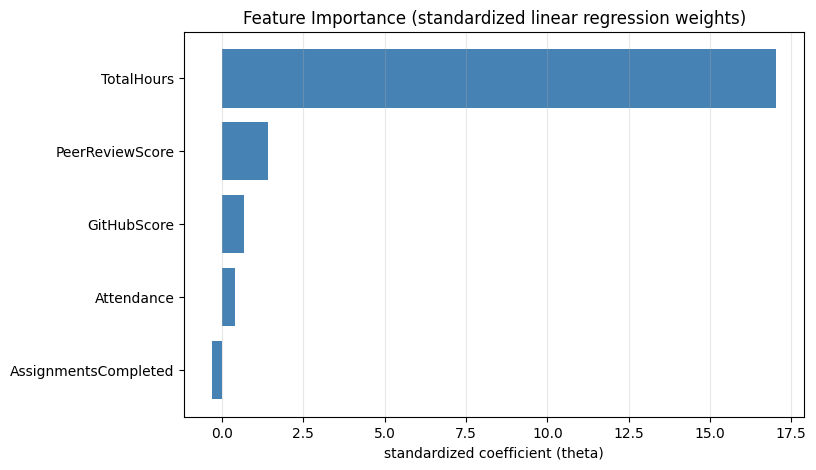

In [45]:
plt.figure(figsize=(8, 5))
plt.barh(coef_df['feature'], coef_df['standardized_weight'], color='steelblue')
plt.xlabel('standardized coefficient (theta)')
plt.title('Feature Importance (standardized linear regression weights)')
plt.grid(alpha=0.3, axis='x')
plt.gca().invert_yaxis()
plt.show()

## 9. Single feature vs five features

A quick comparison against Notebook 1's single-feature (`Attendance`
only) model shows how much the extra features help.

In [46]:
# Re-fit the Notebook-1-style single-feature model here for a fair, apples-to-apples comparison
attendance_idx = feature_cols.index('Attendance')
X_train_single = X_train_scaled[:, [attendance_idx]]
X_test_single = X_test_scaled[:, [attendance_idx]]
X_train_single_design = add_bias(X_train_single)
X_test_single_design = add_bias(X_test_single)

theta_single, _ = gradient_descent(X_train_single_design, Y_train, LEARNING_RATE, N_ITERATIONS)
single_test_metrics = evaluate(Y_test, predict(X_test_single_design, theta_single))

comparison_df = pd.DataFrame(
    [single_test_metrics, test_metrics],
    index=['Attendance only (1 feature)', 'All 5 features']
)
comparison_df.round(4)

,MSE,RMSE,MAE,R2
Attendance only (1 feature),175.4287,13.2449,10.7643,-0.4540
All 5 features,23.8441,4.8830,4.1930,0.8024


## 10. Takeaways

- With five features on very different scales, standardizing every column
  (using train-set statistics, reused for the test set) is what makes a
  single learning rate work for multi-dimensional gradient descent - the
  same lesson from Notebooks 1-2, now applied column-by-column via
  `standardize_features`.
- The vectorised `compute_cost` / `compute_gradients` / `gradient_descent`
  generalize the single-feature versions with no change in *form*, only
  in shape - `theta` is now a vector and `X` a matrix, and NumPy's matrix
  multiplication (`X.dot(theta)`, `X.T.dot(...)`) handles all five
  features at once.
- The standardized coefficients show which mapped features the model
  leans on most heavily - worth cross-checking against the raw
  correlations from Section 1 to see if they tell a consistent story.
- Comparing against the single-feature model quantifies exactly how much
  the extra four features improve test-set R² and error - the
  justification for using the full feature set in the first place.